In [5]:
import torch 
import numpy as np
import matplotlib.pyplot as plt 

[0.         0.12693304 0.25386607 0.38079911 0.50773215 0.63466518
 0.76159822 0.88853126 1.01546429 1.14239733]
[0.         0.25645654 0.51291309 0.76936963 1.02582617 1.28228272
 1.53873926 1.7951958  2.05165235 2.30810889]


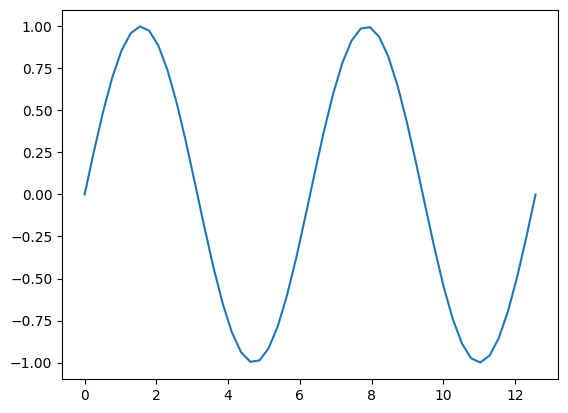

In [6]:
x_train= np.linspace(0,4*np.pi, 100)
y_train= torch.from_numpy(np.sin(x_train))

x_test= np.linspace(0,4*np.pi, 50)
y_test= torch.from_numpy(np.sin(x_test))


print(x_train[:10])
print(x_test[:10])

plt.subplot(1,1,1)
plt.plot(x_test,y_test)

### Question:
we do generate test data with diffrent points to avoid overfit the network
        

In [16]:
torch.manual_seed(42)
# parameters setup
# layer1 params
# w_l1 = torch.rand((1,64))
# b_l1 = torch.rand((1,64))
# # layer2 params
# w_l2 = torch.rand((64,64))
# b_l2 = torch.rand((1,64))

# # layer3 params
# w_l3 = torch.rand((64,))
# b_l3 = torch.rand((1,))

# params = [w_l1, b_l1, w_l2, b_l2,w_l3,b_l3]
# for param in params:
#     param.requires_grad = True
# Layer 1
w_l1 = torch.rand((1, 64))
b_l1 = torch.rand((64,))  # ← Changed from (1, 64) to (64,)

# Layer 2
w_l2 = torch.rand((64, 64))
b_l2 = torch.rand((64,))  # ← Changed from (1, 64) to (64,)

# Layer 3
w_l3 = torch.rand((64,))
b_l3 = torch.rand(())  # ← Changed from (1,) to scalar

params = [w_l1, b_l1, w_l2, b_l2, w_l3, b_l3]
for param in params:
    param.requires_grad = True

In [8]:
# def forward(input):
#     input  = torch.tensor([input]) 
#     result = w_l1.reshape(64,1)@input + b_l1
#     result = torch.relu(result)
#     result = w_l2@torch.squeeze(result) + b_l2
#     result = torch.relu(result)
#     result = w_l3@result.T + b_l3
#     return result
def forward(input):
    x = torch.tensor([[input]])  # Shape: (1, 1)
    
    # Layer 1: (1, 1) @ (1, 64) → (1, 64)
    x = torch.relu(x @ w_l1 + b_l1)
    
    # Layer 2: (1, 64) @ (64, 64) → (1, 64)
    x = torch.relu(x @ w_l2 + b_l2)
    
    # Layer 3: (1, 64) @ (64,) → (1,)
    x = x @ w_l3 + b_l3
    
    return x.squeeze()

In [ ]:
# training loop
epochs = 10000
pred = torch.zeros(len(y_train))
optim = torch.optim.Adam(params,lr=0.002)
epochs_his =[]
loss_his   =[]
for epoch in range(epochs):
    optim.zero_grad()
    # pred = torch.tensor([forward(float(x)) for x in x_test])
    pred = torch.stack([forward(float(x)) for x in x_train])

    loss = torch.mean((pred-y_train)**2)
    
    loss.backward()
    
    optim.step()

    # print("epoch {} || loss {} ".format(epoch, loss))
    # with torch.no_grad():
    epochs_his.append(epoch)
    loss_his.append(loss.item())
        
plt.subplot()
plt.plot(epochs_his,loss_his)
    

tensor([ 0.0000e+00,  2.5365e-01,  4.9072e-01,  6.9568e-01,  8.5514e-01,
         9.5867e-01,  9.9949e-01,  9.7493e-01,  8.8660e-01,  7.4028e-01,
         5.4553e-01,  3.1511e-01,  6.4070e-02, -1.9116e-01, -4.3388e-01,
        -6.4823e-01, -8.2017e-01, -9.3847e-01, -9.9538e-01, -9.8718e-01,
        -9.1441e-01, -7.8183e-01, -5.9811e-01, -3.7527e-01, -1.2788e-01,
         1.2788e-01,  3.7527e-01,  5.9811e-01,  7.8183e-01,  9.1441e-01,
         9.8718e-01,  9.9538e-01,  9.3847e-01,  8.2017e-01,  6.4823e-01,
         4.3388e-01,  1.9116e-01, -6.4070e-02, -3.1511e-01, -5.4553e-01,
        -7.4028e-01, -8.8660e-01, -9.7493e-01, -9.9949e-01, -9.5867e-01,
        -8.5514e-01, -6.9568e-01, -4.9072e-01, -2.5365e-01, -4.8986e-16],
       dtype=torch.float64)
tensor([ 0.0666,  0.2154,  0.7276,  0.9259,  0.9336,  0.9413,  0.8927,  0.7631,
         0.6335,  0.5039,  0.3743,  0.2447,  0.1151, -0.0145, -0.1441, -0.1915,
        -0.1923, -0.1931, -0.1939, -0.1947, -0.1955, -0.1963, -0.1971, -0.1979,
 

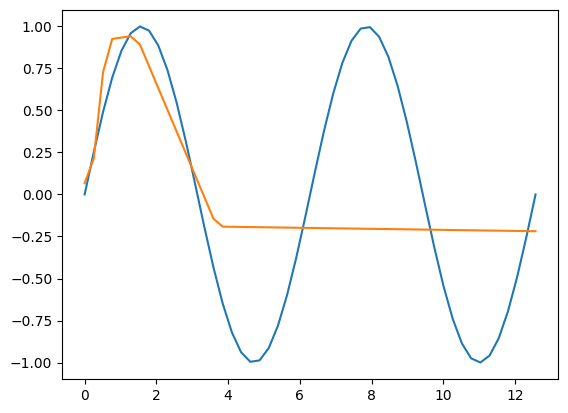

In [15]:
with torch.no_grad():
    y_pred_test =  torch.tensor([forward(float(x)) for x in x_test])
    plt.subplot()
    plt.plot(x_test,y_test)
    plt.plot(x_test,y_pred_test.numpy())
    print(y_test)
    print(y_pred_test)

## Qsts
* Q1: the gradient presents the dervative of the output with respect to a specific param the how much a the increase of this prameter increase the loss,


In [181]:
def forward(input):
    input  = torch.tensor([input]) 
    result = w_l1.reshape(64,1)@input + b_l1
    result = torch.relu(result)
    print("result after 1",result.shape)
    print("result after 1",result.T.shape)
    print("result after 1",torch.squeeze(result).shape)
    result = w_l2@result.T + b_l2
    print("result after 2",result.shape)
    print("result after 2",torch.squeeze(result).shape)
    result = torch.relu(result)
    print("w_l2",w_l2.shape)
    
    result = w_l3@result.T + b_l3
    print("result after 3",result.shape)
    print(w_l3.shape)
    print(b_l3.shape)
    
    return result
print(forward(np.pi))

result after 1 torch.Size([1, 64])
result after 1 torch.Size([64, 1])
result after 1 torch.Size([64])
result after 2 torch.Size([64, 64])
result after 2 torch.Size([64, 64])
w_l2 torch.Size([64, 64])
result after 3 torch.Size([64])
torch.Size([64])
torch.Size([1])
tensor([2295.0630, 1979.1003, 2090.8430, 1977.3025, 2138.7024, 2253.8223,
        2184.6453, 2092.3369, 2394.6646, 2246.1167, 2283.5708, 2332.4453,
        2030.5518, 2143.7607, 2288.4111, 2129.0400, 2379.7510, 2301.7949,
        2362.2075, 2106.1509, 2055.3650, 2437.2932, 2200.5879, 2207.1162,
        2347.2266, 2407.5042, 2305.1973, 2289.0725, 2047.9407, 2064.6123,
        2343.8813, 2660.4390, 2057.9175, 1822.5197, 2198.0239, 1911.1473,
        2175.6331, 2372.3235, 2491.6709, 2021.7102, 2446.5715, 2215.3701,
        2381.6963, 2162.0723, 2259.0264, 2413.5017, 2075.7026, 2216.5032,
        2524.3311, 1949.0115, 2210.2622, 2297.2554, 2209.5596, 2135.6902,
        2103.1228, 2218.9824, 2368.0801, 2345.7158, 2250.3840, 2333.9